# Creación de subgrupos-productos

Replica del enfoque de clustering de conversaciones, en un notebook separado para productos.

In [14]:
# ! pip install pandas pyarrow python-dotenv sentence-transformers scikit-learn matplotlib wordcloud nltk
# ! pip install statsmodels

  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 34.6 MB/s  0:00:00.9 MB/s eta 0:00:01
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] 1/2 [statsmodels]

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from dotenv import load_dotenv
from nltk.corpus import stopwords
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# nltk.download("stopwords", quiet=True)
load_dotenv()
PPATH = os.getenv("PPATH")

print(PPATH)

/Users/daragama/Documents/ProyectosVarios/Datathon2026/datathon26/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/daragama/Documents/ProyectosVarios/Datathon2026/


In [3]:
df = pd.read_csv(PPATH + "data/hey_productos.csv")
print(df.shape)
df.head()


(38909, 13)


,producto_id,user_id,tipo_producto,fecha_apertura,estatus,limite_credito,saldo_actual,utilizacion_pct,tasa_interes_anual,plazo_meses,monto_mensualidad,fecha_ultimo_movimiento,es_dato_sintetico
0,PRD-00000001,USR-00001,cuenta_debito,2023-06-26,activo,NaN,80954.60,NaN,NaN,NaN,NaN,2025-11-27,True
1,PRD-00000002,USR-00001,tarjeta_credito_hey,2022-10-16,activo,144000.0,88790.40,0.6166,35.71,NaN,NaN,2025-09-17,True
2,PRD-00000003,USR-00002,cuenta_debito,2025-04-03,activo,NaN,20712.54,NaN,NaN,NaN,NaN,2025-10-16,True
3,PRD-00000004,USR-00002,tarjeta_credito_hey,2025-07-18,activo,22000.0,6122.60,0.2783,34.08,NaN,NaN,2025-09-15,True
4,PRD-00000005,USR-00003,cuenta_debito,2023-03-26,activo,NaN,3454.65,NaN,NaN,NaN,NaN,2025-09-27,True


In [4]:
# add a new column, product group cuenta, tarjeta, credito, seguro, inversion
def categorize_product(product_name):
    product_name = product_name.lower()
    if "cuenta_" in product_name:
        return "cuenta"
    elif "tarjeta_" in product_name:
        return "tarjeta"
    elif "credito_" in product_name:
        return "credito"
    elif "seguro_" in product_name:
        return "seguro"
    elif "inversion_" in product_name:
        return "inversion"
    else:
        return "otros"
    
df["product_group"] = df["tipo_producto"].apply(categorize_product)
print(df["product_group"].value_counts())

product_group
cuenta       16368
tarjeta       9767
credito       4550
inversion     4474
seguro        3750
Name: count, dtype: int64


In [5]:
# dame la cuenta de proudctos por grupo por usuario
product_counts = df.groupby(["user_id", "product_group"]).size().unstack(fill_value=0)
# print max of each column
print(product_counts.max())
products

product_group
credito      2
cuenta       2
inversion    1
seguro       2
tarjeta      2
dtype: int64


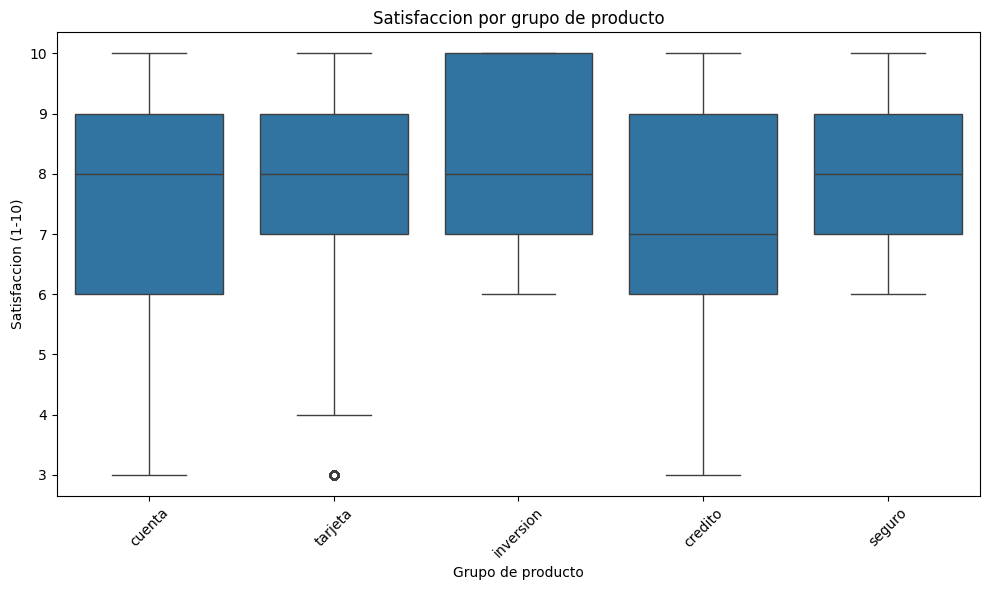

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="product_group", y="satisfaccion_1_10", data=df_merged)
plt.title("Satisfaccion por grupo de producto")
plt.xlabel("Grupo de producto")
plt.ylabel("Satisfaccion (1-10)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

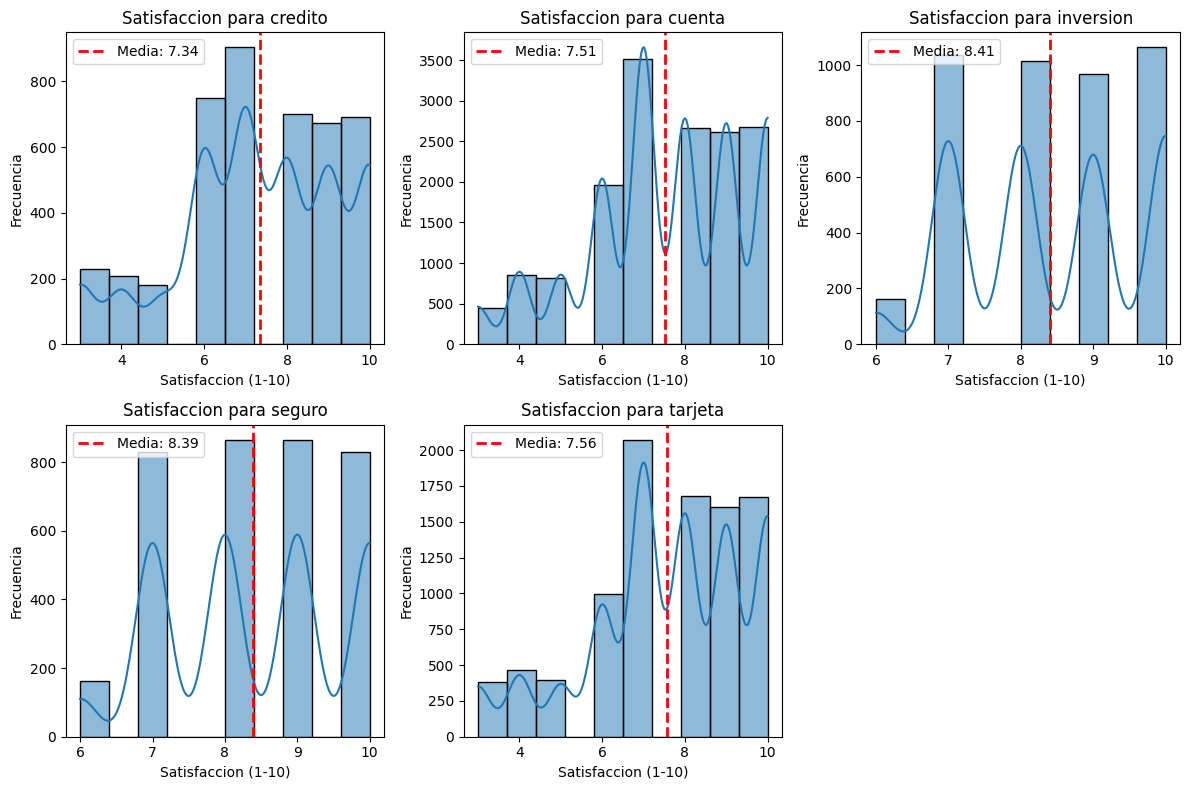

In [18]:
import seaborn as sns

# Ensure df_merged exists
if "df_merged" not in globals():
    if "df_usuarios" not in globals():
        df_usuarios = pd.read_csv(PPATH + "data/hey_clientes.csv")
    df_merged = df.merge(
        df_usuarios[["user_id", "satisfaccion_1_10"]],
        on="user_id",
        how="left",
    )

tmp = df_merged[["product_group", "satisfaccion_1_10"]].dropna()
groups = sorted(tmp["product_group"].unique())[:5]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, group in enumerate(groups):
    ax = axes[i]
    vals = tmp.loc[tmp["product_group"] == group, "satisfaccion_1_10"]

    sns.histplot(vals, bins=10, kde=True, ax=ax)
    media = vals.mean()
    ax.axvline(media, color="red", linestyle="--", linewidth=2, label=f"Media: {media:.2f}")

    ax.set_title(f"Satisfaccion para {group}")
    ax.set_xlabel("Satisfaccion (1-10)")
    ax.set_ylabel("Frecuencia")
    ax.legend()

# Hide empty subplot(s)
for j in range(len(groups), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

<Axes: xlabel='product_group'>

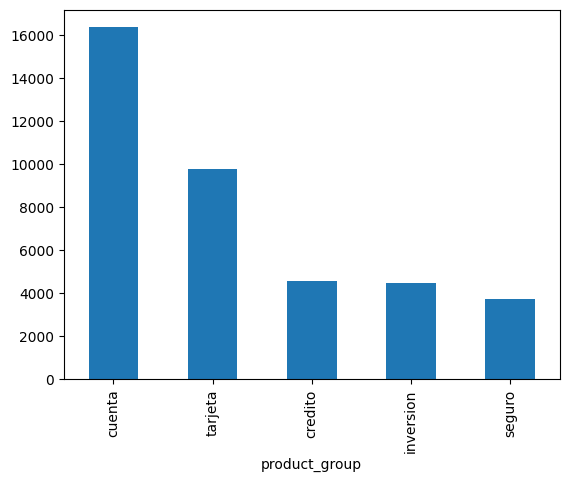

In [21]:
df['product_group'].value_counts().plot(kind='bar')

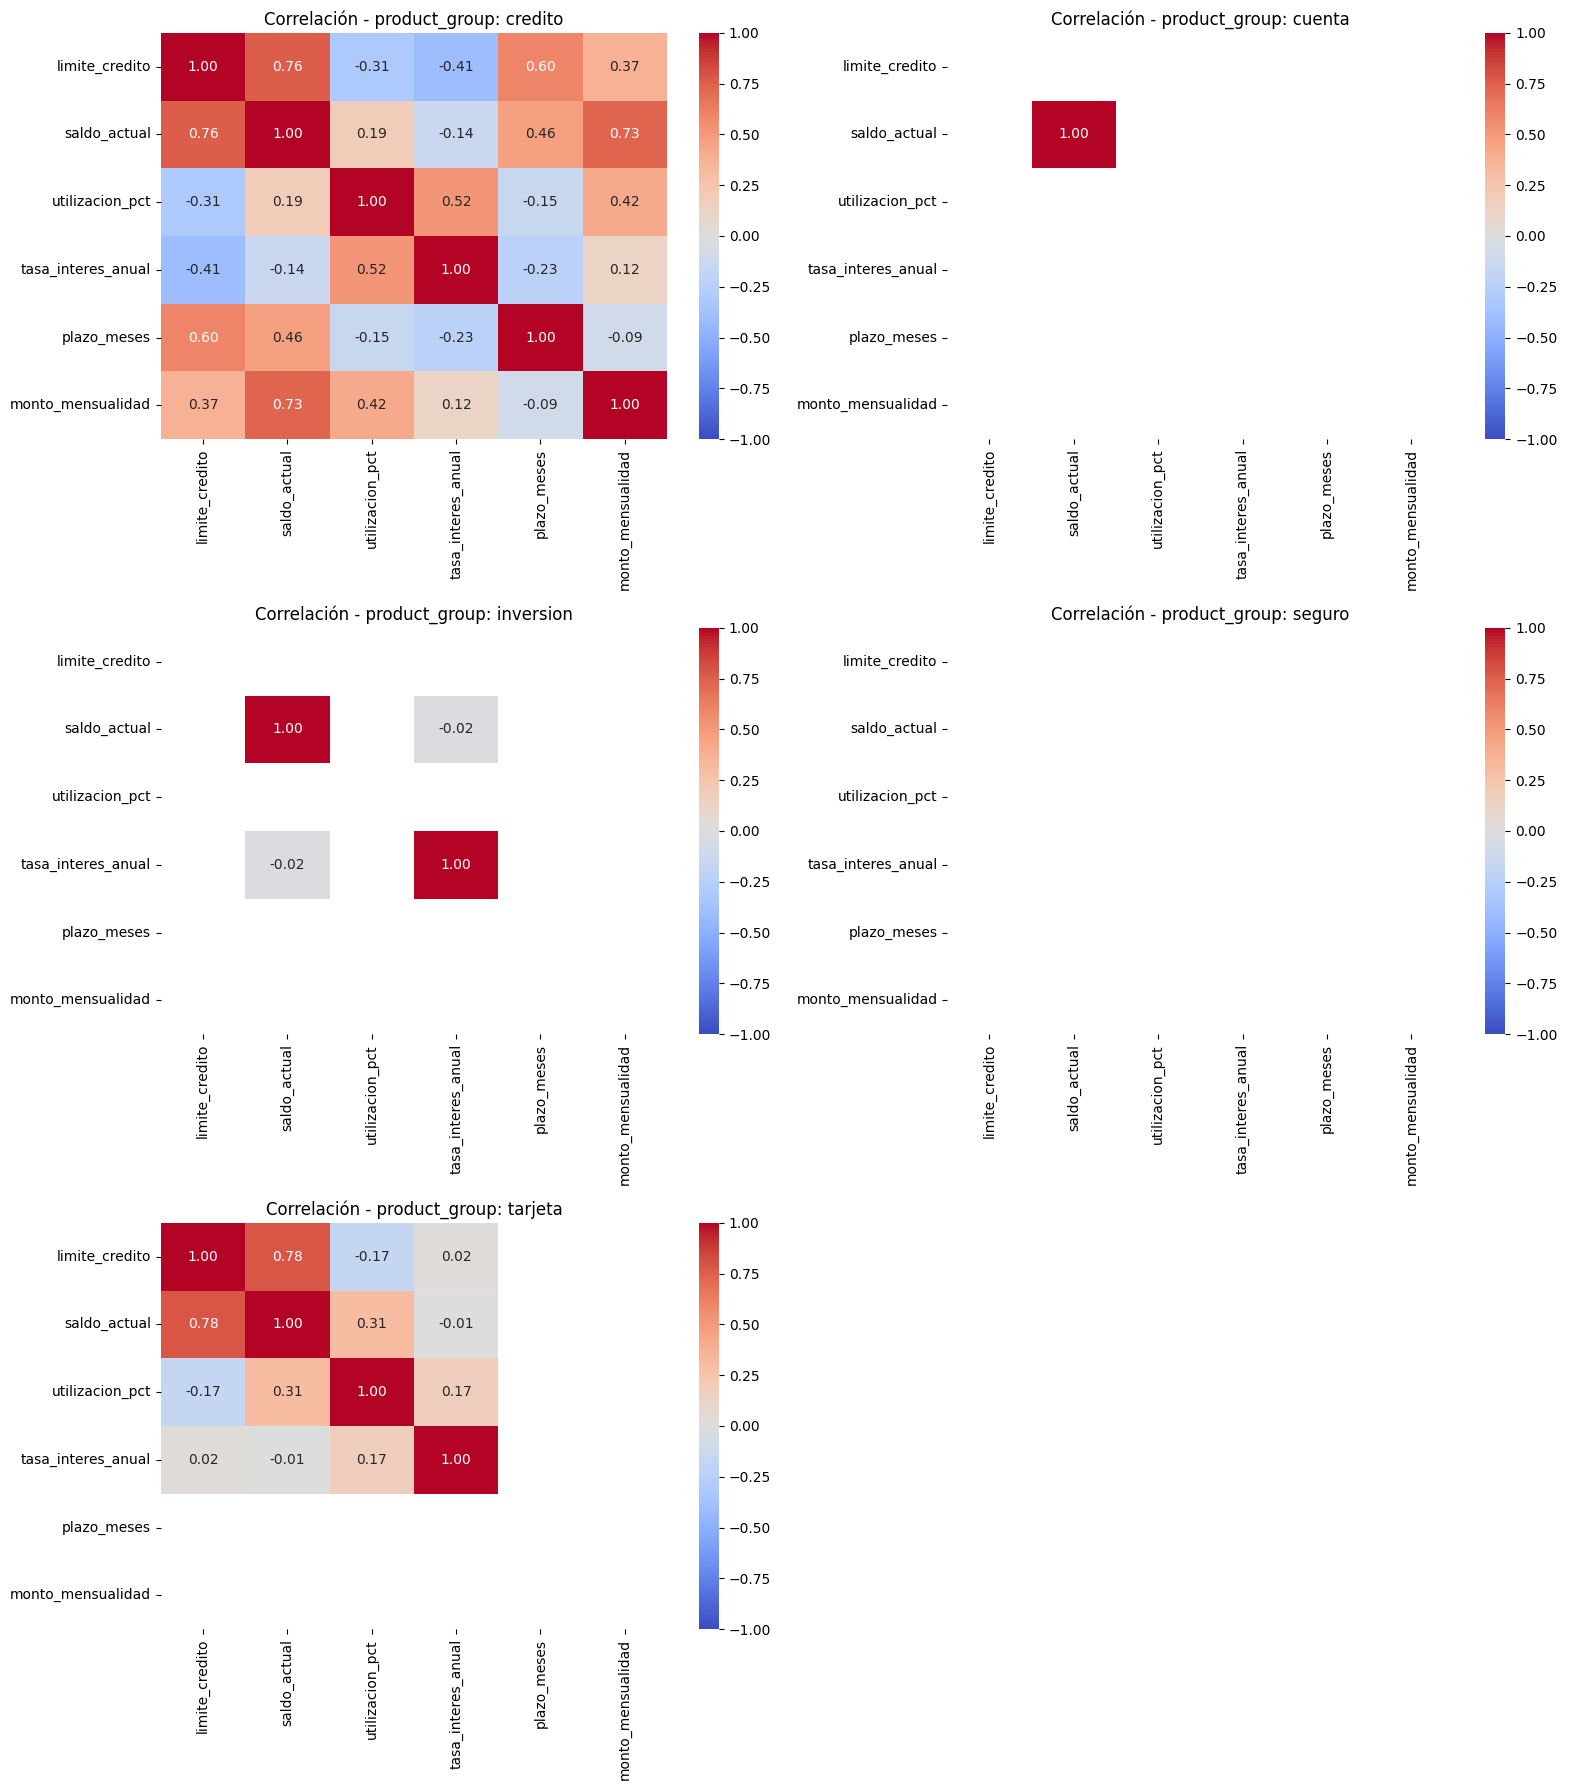

In [19]:
# Matriz de correlación por product_group
import math

if 'product_group' not in df.columns:
    raise ValueError("La columna 'product_group' no existe en df.")

numeric_cols = df.select_dtypes(include='number').columns.tolist()
if not numeric_cols:
    raise ValueError("No hay columnas numéricas para calcular correlaciones.")

# Evita generar una figura vacía para grupos sin suficientes datos.
valid_groups = [
    g for g, sub in df.groupby('product_group', dropna=False)
    if sub[numeric_cols].shape[0] >= 3
]

if not valid_groups:
    raise ValueError("No hay grupos con suficientes filas (>=3) para correlación.")

n_cols = 2
n_rows = math.ceil(len(valid_groups) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 6 * n_rows))
axes = np.array(axes).reshape(-1)

for i, group in enumerate(valid_groups):
    sub = df[df['product_group'] == group][numeric_cols]
    corr = sub.corr()
    sns.heatmap(
        corr,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        center=0,
        ax=axes[i]
    )
    axes[i].set_title(f'Correlación - product_group: {group}')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# JOIN CON SATISFACCION

In [7]:
df_usuarios = pd.read_csv(PPATH + "data/hey_clientes.csv")
print(df_usuarios.shape)
df_usuarios.head()
df_usuarios.columns

(15025, 22)


Index(['user_id', 'edad', 'sexo', 'estado', 'ciudad', 'nivel_educativo',
       'ocupacion', 'ingreso_mensual_mxn', 'antiguedad_dias', 'es_hey_pro',
       'nomina_domiciliada', 'canal_apertura', 'score_buro',
       'dias_desde_ultimo_login', 'preferencia_canal', 'satisfaccion_1_10',
       'recibe_remesas', 'usa_hey_shop', 'idioma_preferido', 'tiene_seguro',
       'num_productos_activos', 'patron_uso_atipico'],
      dtype='str')

In [ ]:
df_merged = df.merge(
    df_usuarios[["user_id", "satisfaccion_1_10"]],
    on="user_id",
    how="left",
)

In [23]:
# Columnas de interés por tipo
cols_credito = [
    "producto_id",
    "user_id",
    "tipo_producto",
    "fecha_apertura",
    "estatus",
    "limite_credito",
    "saldo_actual",
    "utilizacion_pct",
    "tasa_interes_anual",
    "plazo_meses",
    "monto_mensualidad",
    "fecha_ultimo_movimiento"
]

cols_cuenta = [
    "producto_id",
    "user_id",
    "tipo_producto",
    "fecha_apertura",
    "estatus",
    "saldo_actual",
    "fecha_ultimo_movimiento"
]

cols_tarjeta = [
    "producto_id",
    "user_id",
    "tipo_producto",
    "fecha_apertura",
    "estatus",
    "limite_credito",
    "saldo_actual",
    "utilizacion_pct",
    "tasa_interes_anual",
    "fecha_ultimo_movimiento"
]

cols_inversion = [
    "producto_id",
    "user_id",
    "tipo_producto",
    "fecha_apertura",
    "estatus",
    "saldo_actual",
    "tasa_interes_anual",
    "fecha_ultimo_movimiento"
]

cols_seguro = [
    "producto_id",
    "user_id",
    "tipo_producto",
    "fecha_apertura",
    "estatus",
    "fecha_ultimo_movimiento"
]


# DataFrames separados
df_credito = df_merged[df_merged["product_group"] == "credito"][cols_credito].copy()

df_cuenta = df_merged[df_merged["product_group"] == "cuenta"][cols_cuenta].copy()

df_tarjeta = df_merged[df_merged["product_group"] == "tarjeta"][cols_tarjeta].copy()

df_inversion = df_merged[df_merged["product_group"] == "inversion"][cols_inversion].copy()

df_seguro = df_merged[df_merged["product_group"] == "seguro"][cols_seguro].copy()

## Cuenta

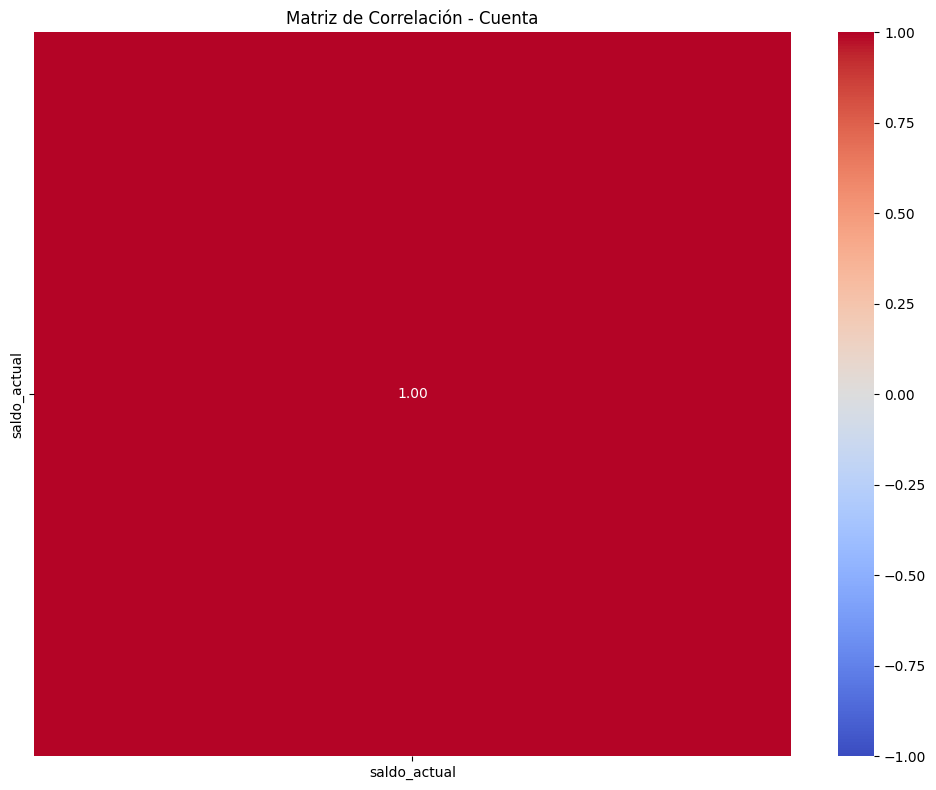

In [31]:
df_cuenta_numeric = df_cuenta.select_dtypes(include='number')
corr_cuenta = df_cuenta_numeric.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_cuenta, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0)
plt.title("Matriz de Correlación - Cuenta")
plt.tight_layout()
plt.show()

## Credito

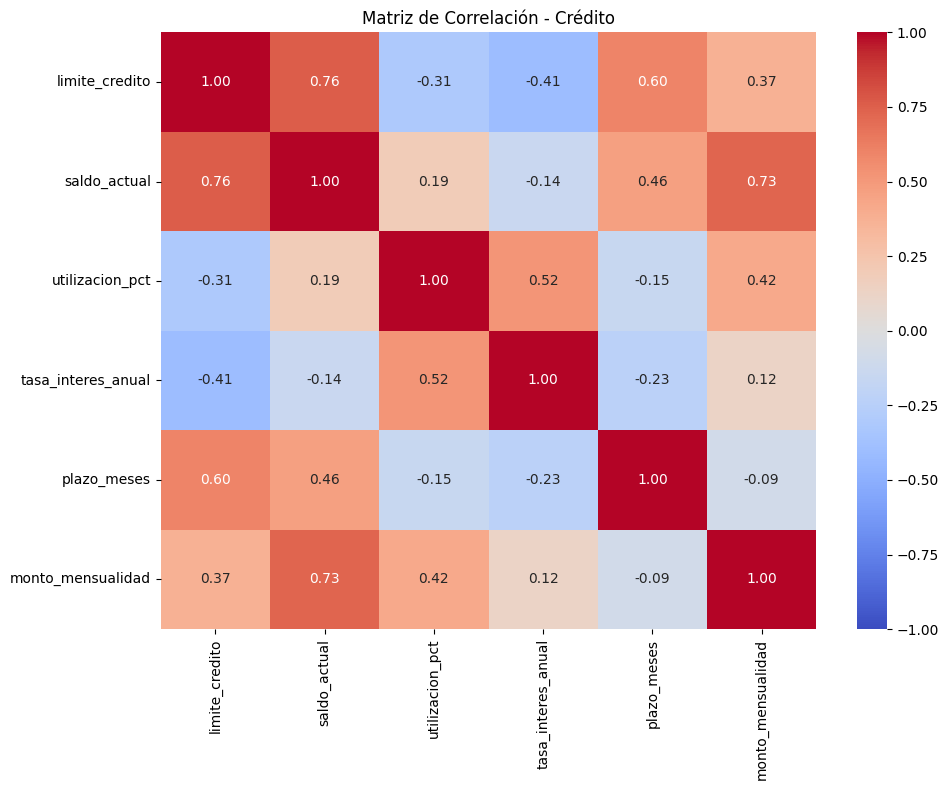

In [30]:
# matriz de correlacion para df_credito
import seaborn as sns
df_credito_numeric = df_credito.select_dtypes(include='number')
corr_credito = df_credito_numeric.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_credito, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0)
plt.title("Matriz de Correlación - Crédito")
plt.tight_layout()
plt.show()